In [1]:
import numpy as np
from tqdm.cli import tqdm
from tqdm import trange
import matplotlib.pyplot as plt
import seaborn as sns
from collections import deque

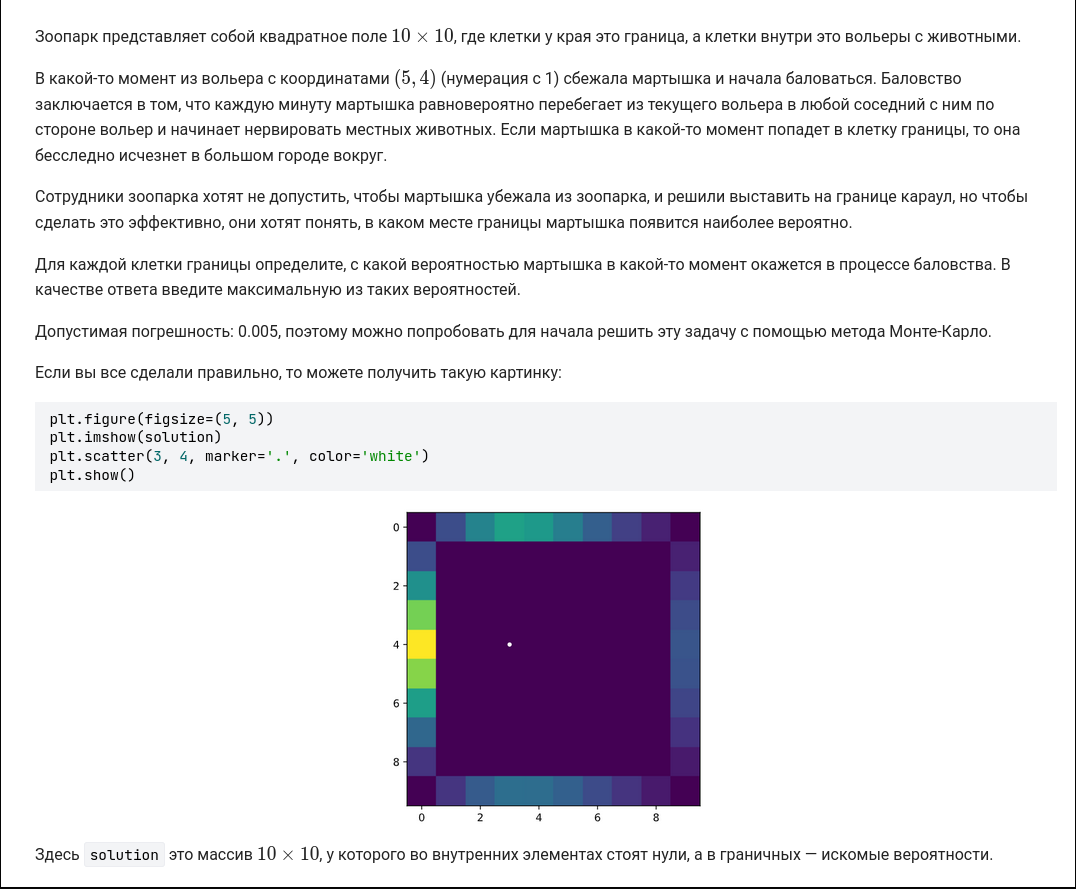

In [2]:
A = np.zeros((10, 10))

epoches = 10000

for epoch in tqdm(range(epoches)):
    cur = [4, 3]

    while cur[0] != 0 and cur[1] != 0 and cur[0] != 9 and cur[1] != 9:
        d = np.random.choice([1, 2, 3, 4])

        if d == 1:
            cur[0] += 1
        if d == 2:
            cur[0] -= 1
        if d == 3:
            cur[1] += 1
        if d == 4:
            cur[1] -= 1

    A[cur[0]][cur[1]] += 1

A /= epoches

  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [00:00<00:00, 13241.29it/s]


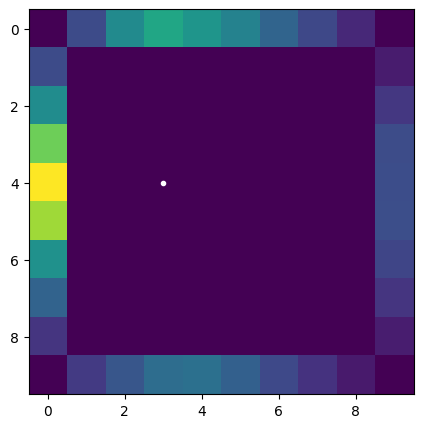

In [3]:
plt.figure(figsize=(5, 5))
plt.imshow(A)
plt.scatter(3, 4, marker='.', color='white')
plt.show()

In [4]:
np.max(A)

np.float64(0.0947)

---

In [5]:
a = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

In [6]:
S = np.zeros((100, 100))
b = np.zeros(100)

b[4 * 10 + 3] = -1

for i in range(100):
    S[i][i] = -1


for i in range(0, 10):
    for j in range(0, 10):
        if i == 4 and j == 3:
            continue
        
        if i == 0:
            if j == 0 or j == 9:
                continue
            S[i * 10 + j][(i + 1) * 10 + j] = 1/4
            continue
        elif i == 9:
            if j == 0 or j == 9:
                continue
            S[i * 10 + j][(i - 1) * 10 + j] = 1/4
            continue

        if j == 0:
            if i == 0 or i == 9:
                continue
            S[i * 10 + j][i * 10 + (j + 1)] = 1/4
            continue
        elif j == 9:
            if i == 0 or i == 9:
                continue
            S[i * 10 + j][i * 10 + (j - 1)] = 1/4
            continue
        
        if i < 8:
            S[i * 10 + j][(i + 1) * 10 + j] = 1/4
        if i > 1:
            S[i * 10 + j][(i - 1) * 10 + j] = 1/4
        if j < 8:
            S[i * 10 + j][i * 10 + (j + 1)] = 1/4
        if j > 1:
            S[i * 10 + j][i * 10 + (j - 1)] = 1/4

solve = np.linalg.solve(S, b).reshape((10, 10))
solve

array([[-0.        ,  0.01148945,  0.02164632,  0.02767502,  0.02599791,
         0.02060611,  0.01458055,  0.00911666,  0.00435159, -0.        ],
       [ 0.01148945,  0.04595779,  0.08658528,  0.11070006,  0.10399165,
         0.08242443,  0.05832219,  0.03646665,  0.01740638,  0.00435159],
       [ 0.02431147,  0.09724587,  0.18968326,  0.25222333,  0.22284212,
         0.16738389,  0.11439768,  0.07013801,  0.03315886,  0.00828971],
       [ 0.03833561,  0.15334244,  0.32267856,  0.48566787,  0.36776959,
         0.24987132,  0.16174663,  0.09652888,  0.04509104,  0.01127276],
       [ 0.04836134,  0.19344535,  0.46202065,  1.        ,  0.51269707,
         0.30258517,  0.18618865,  0.10913982,  0.05067642,  0.01266911],
       [ 0.03960457,  0.1584183 ,  0.3319587 ,  0.49758212,  0.38043353,
         0.26158363,  0.17128298,  0.10316533,  0.04847483,  0.01211871],
       [ 0.02706728,  0.10826914,  0.20981374,  0.27793624,  0.24987132,
         0.19203282,  0.13419432,  0.08376368

In [7]:
for i in range(1, 9):
    for j in range(1, 9):
        solve[i][j] = 0

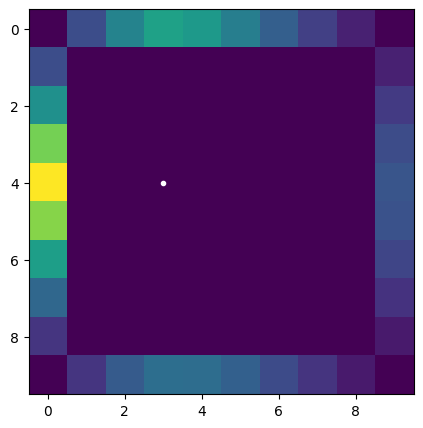

In [8]:
plt.figure(figsize=(5, 5))
plt.imshow(solve)
plt.scatter(3, 4, marker='.', color='white')
plt.show()

In [9]:
solve.max()

np.float64(0.0483613369780077)

In [10]:
import numpy as np

def solve_for_boundary_cell(bi, bj):
    """
    Находит вероятность того, что мартышка выйдет именно через клетку (bi, bj).
    bi, bj — координаты граничной клетки (0-индексация).
    """
    S = np.zeros((100, 100))
    b = np.zeros(100)
    
    for i in range(10):
        for j in range(10):
            cell = i * 10 + j
            
            # Граничные клетки: вероятность = 0 (поглощающие состояния)
            # Уравнение: p = 0, т.е. 1*p = 0
            if i == 0 or i == 9 or j == 0 or j == 9:
                S[cell][cell] = 1
                b[cell] = 0
                continue
            
            # Внутренние клетки: p(i,j) = (1/4) * sum(p(соседей))
            # Но если сосед — это наша целевая граничная клетка (bi,bj),
            # то переход туда даёт вклад 1/4 в вероятность выхода через неё
            
            # Уравнение: p(i,j) - (1/4)*sum(p(внутренних соседей)) = (1/4)*(число соседей = (bi,bj))
            
            S[cell][cell] = 1  # p(i,j)
            
            rhs = 0  # правая часть
            
            for di, dj in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                ni, nj = i + di, j + dj
                neighbor = ni * 10 + nj
                
                if ni == bi and nj == bj:
                    # Сосед — целевая граничная клетка
                    # Переход туда = выход через неё с вероятностью 1
                    rhs += 1/4
                elif 1 <= ni <= 8 and 1 <= nj <= 8:
                    # Сосед — внутренняя клетка
                    S[cell][neighbor] = -1/4
                # Если сосед — другая граничная клетка, то p(сосед) = 0, ничего не добавляем
            
            b[cell] = rhs
    
    solution = np.linalg.solve(S, b)
    return solution

# Стартовая позиция мартышки: (5,4) в 1-индексации = (4,3) в 0-индексации
start_cell = 4 * 10 + 3

max_prob = 0
max_cell = None
results = np.zeros((10, 10))

# Перебираем все граничные клетки
for i in range(10):
    for j in range(10):
        if i == 0 or i == 9 or j == 0 or j == 9:
            # Это граничная клетка
            solution = solve_for_boundary_cell(i, j)
            prob = solution[start_cell]
            results[i][j] = prob
            
            if prob > max_prob:
                max_prob = prob
                max_cell = (i, j)

print("Вероятности выхода через каждую граничную клетку:")
print(np.round(results, 4))
print()
print(f"Максимальная вероятность: {max_prob}")
print(f"Клетка (0-индексация): {max_cell}")
print(f"Клетка (1-индексация): ({max_cell[0]+1}, {max_cell[1]+1})")
print(f"Сумма вероятностей (должна быть 1): {results.sum():.6f}")

Вероятности выхода через каждую граничную клетку:
[[0.     0.0225 0.0424 0.0542 0.0509 0.0404 0.0286 0.0179 0.0085 0.    ]
 [0.0225 0.     0.     0.     0.     0.     0.     0.     0.     0.0085]
 [0.0476 0.     0.     0.     0.     0.     0.     0.     0.     0.0162]
 [0.0751 0.     0.     0.     0.     0.     0.     0.     0.     0.0221]
 [0.0947 0.     0.     0.     0.     0.     0.     0.     0.     0.0248]
 [0.0776 0.     0.     0.     0.     0.     0.     0.     0.     0.0237]
 [0.053  0.     0.     0.     0.     0.     0.     0.     0.     0.0196]
 [0.0318 0.     0.     0.     0.     0.     0.     0.     0.     0.0137]
 [0.0147 0.     0.     0.     0.     0.     0.     0.     0.     0.007 ]
 [0.     0.0147 0.027  0.0342 0.034  0.0289 0.0218 0.0142 0.007  0.    ]]

Максимальная вероятность: 0.09473177731553663
Клетка (0-индексация): (4, 0)
Клетка (1-индексация): (5, 1)
Сумма вероятностей (должна быть 1): 1.000000


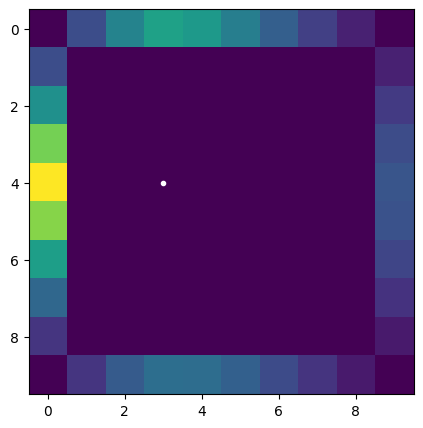

In [11]:
plt.figure(figsize=(5, 5))
plt.imshow(results)
plt.scatter(3, 4, marker='.', color='white')
plt.show()

---

Рассмотрим клетчатую пластину 100×100, нумерация клеток с 1. Предположим, что на граничных клетках этой пластины поддерживается температура в 0 градусов Цельсия. Пусть также на верхнему крае пластины с 40 по 60 клетку поддерживается температура в 100 градусов Цельсия. Если пластина находится в таком состоянии достаточно долго, то она  придет в состояние термодинамического равновесия: температура в каждой неграничной клетке будет равна средней температуре ее соседей по стороне.

Найдите температуру в клетке (50,50) в состоянии равновесия.

Допустимая погрешность: $10^{-9}$.

Если у вас все получилось правильно, то вы можете получить такую картинку:
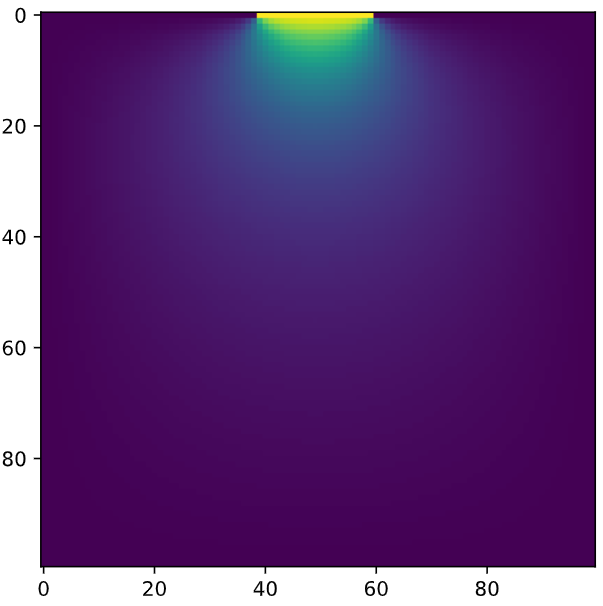

```
plt.figure(figsize=(5, 5))
plt.imshow(solution)
plt.show()
```

In [12]:
# A = np.zeros((100, 100))
# A[0][39:60] = 100

# def is_static(p):
#     return p[0] == 0 or p[1] == 0

# epoches = 200000

# for epoch in trange(epoches):
#     for i in range(1, 99):
#         for j in range(1, 99):
#             A[i, j] = A[i - 1, j] / 4 + A[i + 1, j] / 4 + A[i, j + 1] / 4 + A[i, j - 1] / 4

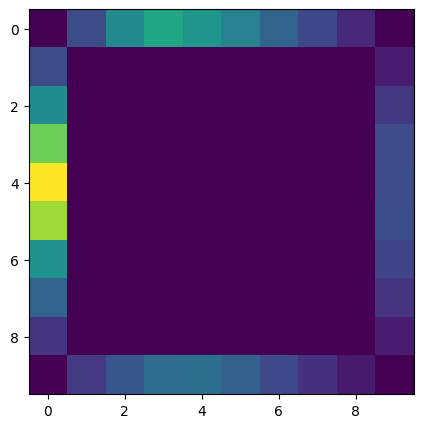

In [13]:
plt.figure(figsize=(5, 5))
plt.imshow(A)
plt.show()

In [14]:
# A[49, 49]

---

In [15]:
# import numpy as np
# g = generate(1000000)
# print((g == 1).sum() / g.shape[0] * 10 - 3)


---

In [16]:
def generate(n):
    return np.random.choice([0, 1, 2], n)

---

In [17]:
def show_log_heatmap(field, P):
    H = np.where((field == 1) | (P <= 0), 1.0, np.log(P))
    a, b = H.shape
    plt.figure(figsize=(5,5)); plt.imshow(H); plt.colorbar()
    plt.xticks(range(b), range(1, b+1)); plt.yticks(range(a), range(1, a+1))
    plt.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
    plt.gca().xaxis.set_label_position("top")
    plt.tight_layout(); plt.show()

[ 0.47368421  0.          0.21052632  0.          0.47368421  0.47368421
  0.42105263  0.          0.          0.52631579  0.57894737  0.78947368
  0.52631579  0.52631579  0.         -5.        ]


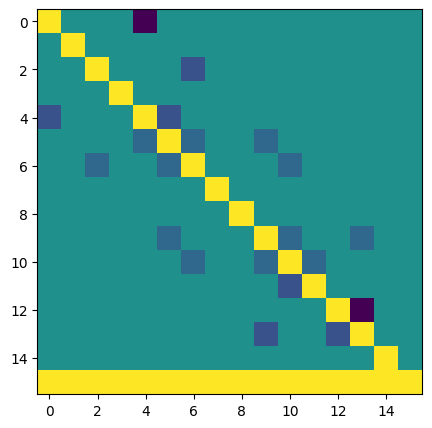

In [18]:
field = np.array([
    [0,1,0,1],
    [0,0,0,1],
    [1,0,0,0],
    [0,0,1,0],
], dtype=int)

start = (0, 0)
finish = (3, 3)

A = -np.ones((field.shape[0] + 2, field.shape[1] + 2))
for i in range(1, field.shape[0] + 1):
    for j in range(1, field.shape[1] + 1):
        A[i][j] = field[i-1][j-1]

S = np.zeros((field.shape[0] * field.shape[1], field.shape[0] * field.shape[1]))
b = np.zeros(field.shape[0] * field.shape[1])

S[finish[0] * field.shape[0] + finish[1]] = 1
b[finish[0] * field.shape[0] + finish[1]] = 1

for i in range(1, field.shape[0] + 1):
    for j in range(1, field.shape[1] + 1):
        cell = (i - 1) * field.shape[0] + (j - 1)

        S[cell][cell] = 1
        b[cell] = 0

        if A[i][j] == 1 or (i == finish[0] + 1 and j == finish[1] + 1):
            continue

        bl, wh = 0, 0
        for di, dj in ([1, 0], [-1, 0], [0, 1], [0, -1]):
            ni, nj = i + di, j + dj
            if A[ni][nj] == 1:
                bl += 1
            if A[ni][nj] == 0:
                wh += 1
        
        for di, dj in ([1, 0], [-1, 0], [0, 1], [0, -1]):
            ni, nj = i + di, j + dj
            n_cell = (ni - 1) * field.shape[0] + (nj - 1)
            if ni == finish[0] + 1 and nj == finish[1] + 1:
                b[cell] += 1 / (wh + bl - 1)
            elif A[ni][nj] == 0:
                S[cell][n_cell] = -(1 / (wh + bl - 1))

solve = np.linalg.solve(S, b)

print(solve)

plt.figure(figsize=(5, 5))
plt.imshow(S)
plt.show()

In [19]:
solve[0]

np.float64(0.47368421052631526)

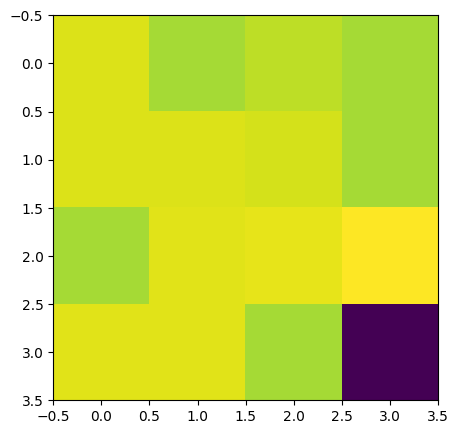

In [20]:
plt.figure(figsize=(5, 5))
plt.imshow(solve.reshape(4, 4))
plt.show()

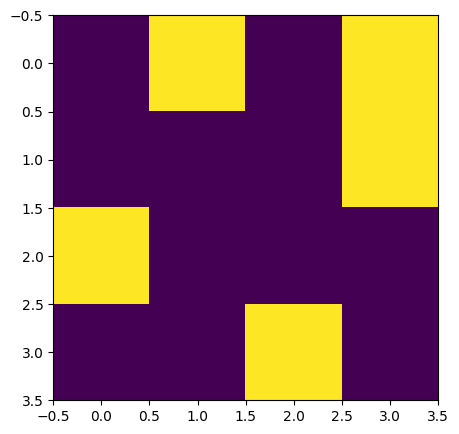

In [21]:
plt.figure(figsize=(5, 5))
plt.imshow(field)
plt.show()

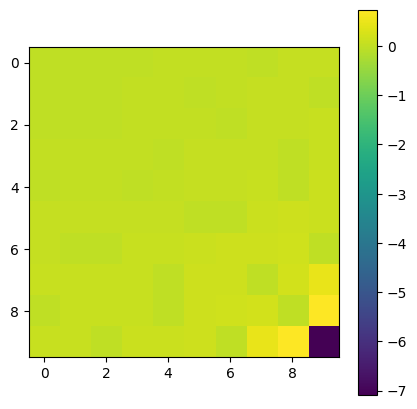

In [24]:
import numpy as np

# 0 = лёд, 1 = лужа
field = np.array([
    [0,0,0,1,0,0,0,1,0,0],
    [0,1,0,0,0,1,0,0,0,1],
    [0,1,1,0,0,0,1,0,0,0],
    [0,0,0,0,1,0,0,0,1,0],
    [1,0,0,1,0,0,0,0,1,0],
    [0,0,0,0,0,1,1,0,0,0],
    [0,1,1,0,0,0,0,0,0,1],
    [0,0,0,0,1,0,0,1,0,0],
    [1,0,0,0,1,0,0,0,1,0],
    [0,0,1,0,0,0,1,0,0,0],
], dtype=int)

start = (0, 0)
finish = (9, 9)

A = -np.ones((field.shape[0] + 2, field.shape[1] + 2))
for i in range(1, field.shape[0] + 1):
    for j in range(1, field.shape[1] + 1):
        A[i][j] = field[i-1][j-1]

S = np.zeros((field.shape[0] * field.shape[1], field.shape[0] * field.shape[1]))
b = np.zeros(field.shape[0] * field.shape[1])

S[finish[0] * field.shape[0] + finish[1]] = 1
b[finish[0] * field.shape[0] + finish[1]] = 1

for i in range(1, field.shape[0] + 1):
    for j in range(1, field.shape[1] + 1):
        cell = (i - 1) * field.shape[0] + (j - 1)

        S[cell][cell] = 1
        b[cell] = 0

        if A[i][j] == 1 or (i == finish[0] + 1 and j == finish[1] + 1):
            continue

        bl, wh = 0, 0
        for di, dj in ([1, 0], [-1, 0], [0, 1], [0, -1]):
            ni, nj = i + di, j + dj
            if A[ni][nj] == 1:
                bl += 1
            if A[ni][nj] == 0:
                wh += 1
        
        for di, dj in ([1, 0], [-1, 0], [0, 1], [0, -1]):
            ni, nj = i + di, j + dj
            n_cell = (ni - 1) * field.shape[0] + (nj - 1)
            if ni == finish[0] + 1 and nj == finish[1] + 1:
                b[cell] += 1 / (wh + bl - 1)
            elif A[ni][nj] == 0:
                S[cell][n_cell] = -(1 / (wh + bl - 1))

solve = np.linalg.solve(S, b)

plt.figure(figsize=(5, 5));
plt.imshow(solve.reshape(field.shape[0], field.shape[1]))
plt.colorbar()
plt.show()

In [ ]:
solve[0]

np.float64(-0.015362246583434668)

In [25]:
import numpy as np
from scipy import sparse

field = np.array([
    [0,0,0,1,0,0,0,1,0,0],
    [0,1,0,0,0,1,0,0,0,1],
    [0,1,1,0,0,0,1,0,0,0],
    [0,0,0,0,1,0,0,0,1,0],
    [1,0,0,1,0,0,0,0,1,0],
    [0,0,0,0,0,1,1,0,0,0],
    [0,1,1,0,0,0,0,0,0,1],
    [0,0,0,0,1,0,0,1,0,0],
    [1,0,0,0,1,0,0,0,1,0],
    [0,0,1,0,0,0,1,0,0,0],
], dtype=int)

rows, cols = field.shape
start = (0, 0)
finish = (rows-1, cols-1)

def idx(i, j):
    return i * cols + j

def neighbors(i, j):
    res = []
    for di, dj in [(-1,0),(1,0),(0,-1),(0,1)]:
        ni, nj = i+di, j+dj
        if 0 <= ni < rows and 0 <= nj < cols:
            res.append((ni, nj))
    return res

N = rows * cols

# Value iteration
V = np.zeros(N)
V[idx(*finish)] = 1.0

for iteration in range(10000):
    V_new = V.copy()
    for i in range(rows):
        for j in range(cols):
            if (i,j) == finish:
                V_new[idx(i,j)] = 1.0
                continue
            if field[i][j] == 1:  # лужа
                V_new[idx(i,j)] = 0.0
                continue
            
            nbrs = neighbors(i, j)
            n = len(nbrs)
            
            # Значения соседей (лужа = 0)
            vals = []
            for ni, nj in nbrs:
                if field[ni][nj] == 1:
                    vals.append(0.0)
                else:
                    vals.append(V[idx(ni, nj)])
            
            best = -1
            
            # Вариант 1: не исключаем ничего
            if n > 0:
                best = max(best, sum(vals) / n)
            
            # Вариант 2: исключаем каждого соседа по очереди
            if n >= 2:
                for k in range(n):
                    s = (sum(vals) - vals[k]) / (n - 1)
                    best = max(best, s)
            
            V_new[idx(i,j)] = best
    
    if np.max(np.abs(V_new - V)) < 1e-15:
        print(f"Converged at iteration {iteration}")
        break
    V = V_new

print(f"Вероятность: {V[idx(*start)]}")

Converged at iteration 2199
Вероятность: 0.04159492388785928


Исключаем вниз: 0.005241619873617128
Исключаем вправо: 0.04159492388788794

Лучшая стратегия: exclude_right
Вероятность: 0.04159492388788794


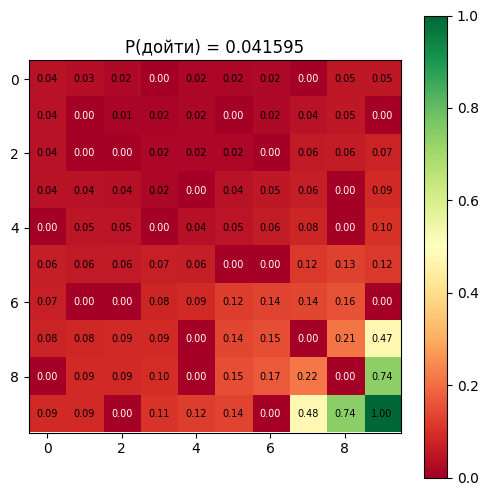

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# 0 = лёд, 1 = лужа
field = np.array([
    [0,0,0,1,0,0,0,1,0,0],
    [0,1,0,0,0,1,0,0,0,1],
    [0,1,1,0,0,0,1,0,0,0],
    [0,0,0,0,1,0,0,0,1,0],
    [1,0,0,1,0,0,0,0,1,0],
    [0,0,0,0,0,1,1,0,0,0],
    [0,1,1,0,0,0,0,0,0,1],
    [0,0,0,0,1,0,0,1,0,0],
    [1,0,0,0,1,0,0,0,1,0],
    [0,0,1,0,0,0,1,0,0,0],
], dtype=int)

start = (0, 0)
finish = (9, 9)

A = -np.ones((field.shape[0] + 2, field.shape[1] + 2))
for i in range(1, field.shape[0] + 1):
    for j in range(1, field.shape[1] + 1):
        A[i][j] = field[i-1][j-1]

def solve_with_exclusion(excluded_cell=None):
    """
    Решает СЛУ с заданным исключением для стартовой клетки.
    excluded_cell = (di, dj) - какое направление исключить из (0,0)
    """
    S = np.zeros((field.shape[0] * field.shape[1], field.shape[0] * field.shape[1]))
    b = np.zeros(field.shape[0] * field.shape[1])

    for i in range(1, field.shape[0] + 1):
        for j in range(1, field.shape[1] + 1):
            cell = (i - 1) * field.shape[1] + (j - 1)

            S[cell][cell] = 1
            b[cell] = 0

            if A[i][j] == 1 or (i == finish[0] + 1 and j == finish[1] + 1):
                if i == finish[0] + 1 and j == finish[1] + 1:
                    b[cell] = 1
                continue

            # Считаем соседей
            bl, wh = 0, 0
            neighbors = []
            for di, dj in ([1, 0], [-1, 0], [0, 1], [0, -1]):
                ni, nj = i + di, j + dj
                if A[ni][nj] == 1:
                    bl += 1
                    neighbors.append((di, dj, 'bl'))
                elif A[ni][nj] == 0:
                    wh += 1
                    neighbors.append((di, dj, 'wh'))
            
            # Определяем какое направление исключаем
            if i == 1 and j == 1 and excluded_cell is not None:
                # Для стартовой клетки используем заданное исключение
                exclude_dir = excluded_cell
            else:
                # Для остальных клеток исключаем первую лужу (если есть)
                exclude_dir = None
                for di, dj, typ in neighbors:
                    if typ == 'bl':
                        exclude_dir = (di, dj)
                        break
                # Если луж нет, исключаем первого белого соседа
                if exclude_dir is None and len(neighbors) > 0:
                    exclude_dir = (neighbors[0][0], neighbors[0][1])
            
            # Считаем активных соседей (без исключённого)
            active_count = 0
            for di, dj, typ in neighbors:
                if (di, dj) != exclude_dir:
                    active_count += 1
            
            if active_count == 0:
                continue
            
            prob = 1.0 / active_count
            
            for di, dj in ([1, 0], [-1, 0], [0, 1], [0, -1]):
                if (di, dj) == exclude_dir:
                    continue
                    
                ni, nj = i + di, j + dj
                n_cell = (ni - 1) * field.shape[1] + (nj - 1)
                
                if ni == finish[0] + 1 and nj == finish[1] + 1:
                    b[cell] += prob
                elif A[ni][nj] == 0:
                    S[cell][n_cell] -= prob
                # Если лужа — ничего не добавляем (V=0)

    return np.linalg.solve(S, b)

# Для стартовой клетки (0,0) соседи: (1,0) вниз и (0,1) вправо
# Пробуем оба варианта исключения
results = {}

# Исключаем движение вниз (1,0)
sol1 = solve_with_exclusion((1, 0))
results['exclude_down'] = sol1[0]

# Исключаем движение вправо (0,1)
sol2 = solve_with_exclusion((0, 1))
results['exclude_right'] = sol2[0]

print("Исключаем вниз:", results['exclude_down'])
print("Исключаем вправо:", results['exclude_right'])

best_strategy = max(results, key=results.get)
best_prob = results[best_strategy]
best_solution = sol1 if best_strategy == 'exclude_down' else sol2

print(f"\nЛучшая стратегия: {best_strategy}")
print(f"Вероятность: {best_prob}")

plt.figure(figsize=(6, 6))
plt.imshow(best_solution.reshape(field.shape[0], field.shape[1]), cmap='RdYlGn', vmin=0, vmax=1)
plt.colorbar()
for i in range(field.shape[0]):
    for j in range(field.shape[1]):
        color = 'white' if field[i][j] == 1 else 'black'
        plt.text(j, i, f'{best_solution[i * field.shape[1] + j]:.2f}', 
                 ha='center', va='center', fontsize=7, color=color)
plt.title(f'P(дойти) = {best_prob:.6f}')
plt.show()